In [41]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
import os
import kagglehub

# Download latest version
path = kagglehub.dataset_download("novandraanugrah/xauusd-gold-price-historical-data-2004present")

for p in os.listdir(path):
    print(p)
    path += "/" + p

print("Path to dataset files:", path)

100%|██████████| 73.6M/73.6M [00:07<00:00, 10.9MB/s]

Extracting files...


XAU_1m_data.csv
Path to dataset files: C:\Users\User\.cache\kagglehub\datasets\novandraanugrah\xauusd-gold-price-historical-data-2004present\versions\44/XAU_1m_data.csv


In [3]:
df = pd.read_csv(path)
print (f"row: {len(df)}")
print (f"column: {len(df.columns)}\n")
print(df.head())

row: 6822714
column: 6

                  Date   Open   High    Low  Close  Volume
0  2004-06-11 07:18:00  384.0  384.1  384.0  384.0     3.0
1  2004-06-11 07:23:00  384.1  384.1  384.0  384.0     2.0
2  2004-06-11 07:24:00  383.8  383.8  383.8  383.8     1.0
3  2004-06-11 07:25:00  383.8  384.3  383.8  384.3     3.0
4  2004-06-11 07:27:00  383.8  383.8  383.8  383.8     1.0


In [4]:
df.isnull().sum()

Date      0
Open      0
High      0
Low       0
Close     0
Volume    0
dtype: int64

In [5]:
df.describe()

,Open,High,Low,Close,Volume
count,6.822714e+06,6.822714e+06,6.822714e+06,6.822714e+06,6.822714e+06
mean,1.513602e+03,1.513838e+03,1.513362e+03,1.513601e+03,7.172995e+01
std,6.908961e+02,6.910553e+02,6.907317e+02,6.908969e+02,1.192559e+02
min,3.811000e+02,3.811000e+02,3.811000e+02,3.811000e+02,1.000000e+00
25%,1.184560e+03,1.184740e+03,1.184400e+03,1.184570e+03,1.700000e+01
50%,1.329910e+03,1.330110e+03,1.329730e+03,1.329910e+03,4.500000e+01
75%,1.785590e+03,1.785830e+03,1.785330e+03,1.785590e+03,8.500000e+01
max,5.593530e+03,5.595418e+03,5.591143e+03,5.593191e+03,8.305000e+03


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6822714 entries, 0 to 6822713
Data columns (total 6 columns):
 #   Column  Dtype  
---  ------  -----  
 0   Date    object 
 1   Open    float64
 2   High    float64
 3   Low     float64
 4   Close   float64
 5   Volume  float64
dtypes: float64(5), object(1)
memory usage: 312.3+ MB


### change feature time to datetime

In [7]:
df["Date"] = pd.to_datetime(df["Date"], utc=True, errors="coerce")
df = df.dropna(subset=["Date"]).reset_index(drop=True)

## Visualization

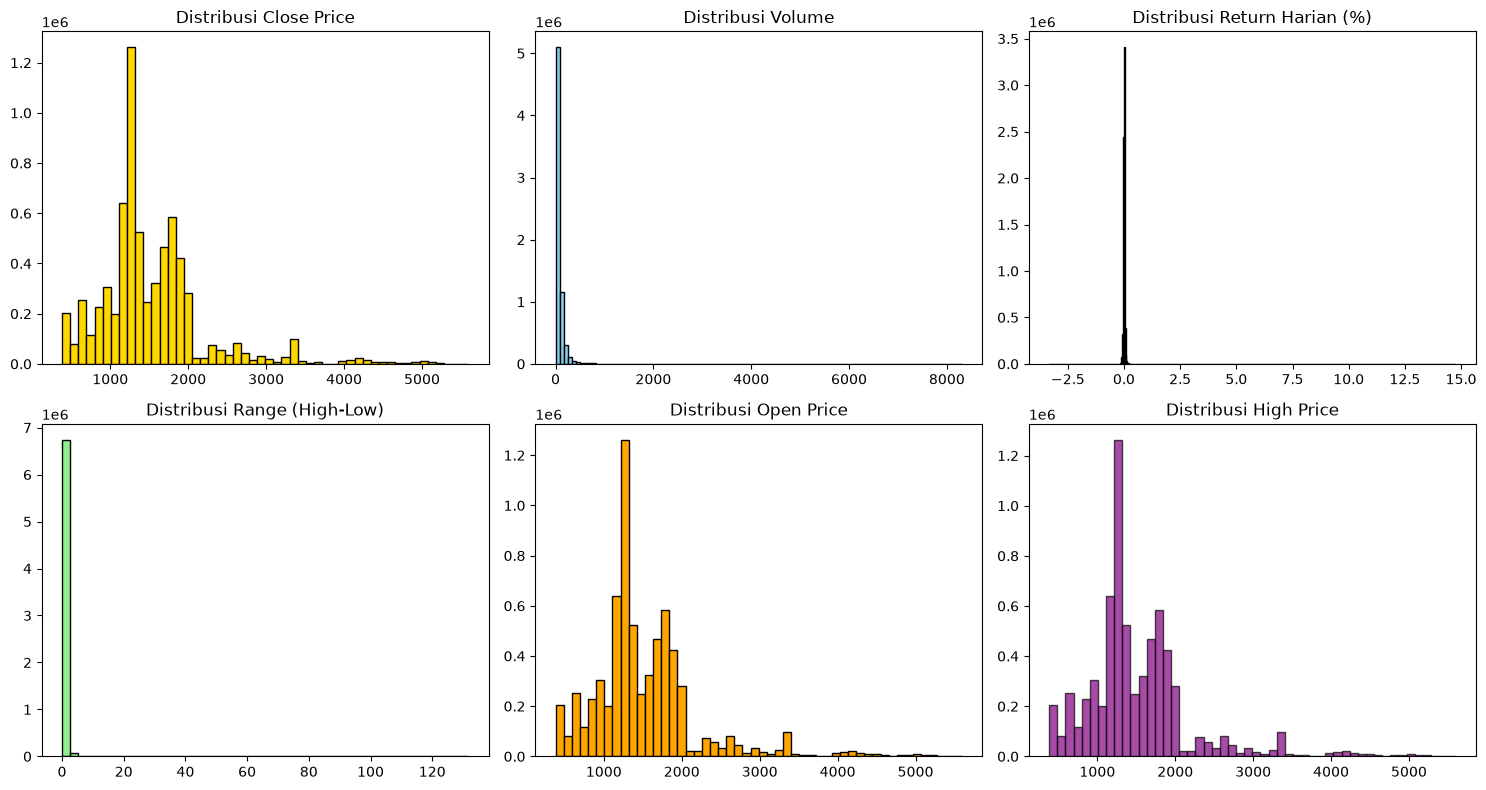

In [ ]:
fig, ax = plt.subplots(2,3, figsize=(15,8))

# Histogram harga Close
ax[0,0].hist(df['Close'], bins=50, color='gold', edgecolor='black')
ax[0,0].set_title('Distribusi Close Price')

# Histogram Volume
ax[0,1].hist(df['Volume'], bins=100, color='skyblue', edgecolor='black')
ax[0,1].set_title('Distribusi Volume')

# Histogram Return harian
df['Return'] = df['Close'].pct_change() * 100
ax[0,2].hist(df['Return'].dropna(), bins=50, color='salmon', edgecolor='black')
ax[0,2].set_title('Distribusi Return Harian (%)')

# Histogram High-Low range
df['Range'] = df['High'] - df['Low']
ax[1,0].hist(df['Range'], bins=50, color='lightgreen', edgecolor='black')
ax[1,0].set_title('Distribusi Range (High-Low)')

ax[1,1].hist(df['Open'], bins=50, color='orange', edgecolor='black')
ax[1,1].set_title('Distribusi Open Price')

ax[1,2].hist(df['High'], bins=50, color='purple', alpha=0.7, edgecolor='black')
ax[1,2].set_title('Distribusi High Price')

plt.tight_layout()
plt.show()

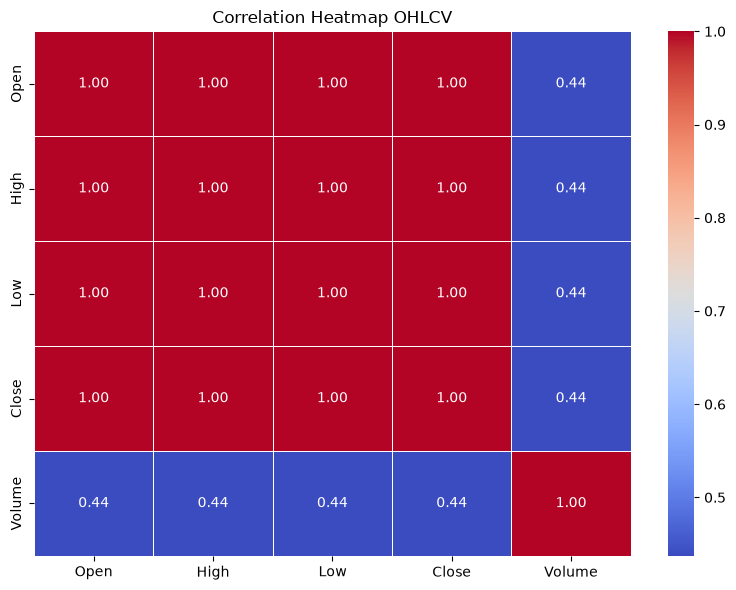

In [42]:
plt.figure(figsize=(8, 6))
corr = df[['Open', 'High', 'Low', 'Close', 'Volume']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap OHLCV')
plt.tight_layout()
plt.show()

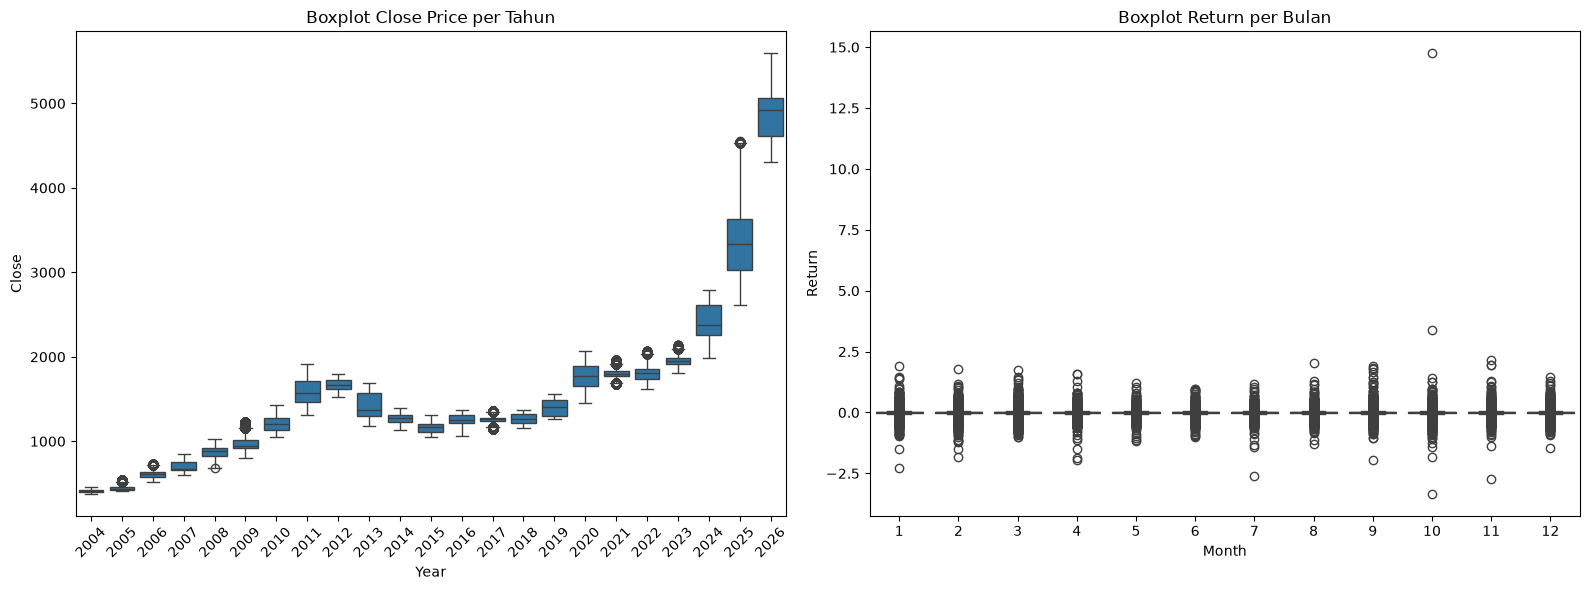

In [43]:
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Boxplot Close price per tahun
sns.boxplot(x='Year', y='Close', data=df, ax=axes[0])
axes[0].set_title('Boxplot Close Price per Tahun')
axes[0].tick_params(axis='x', rotation=45)

# Boxplot Return per bulan (deteksi outlier)
sns.boxplot(x='Month', y='Return', data=df, ax=axes[1])
axes[1].set_title('Boxplot Return per Bulan')

plt.tight_layout()
plt.show()

## Save Dataset

In [44]:
df_train = df[df["Date"].dt.year <= 2022]
df_test = df[df["Date"].dt.year > 2022]

In [45]:
print((len(df_train) + len(df_test)) == len(df))

True


In [46]:
print(len(df_train))
print(len(df_test))

5740286
1082428


In [25]:
df_train.to_csv("../data/gold_2004-2022.csv", index=False)
df_test.to_csv("../data/gold_2023-2026.csv", index=False)

# The features below are no longer used due to the new dataset.

### create rsi feature

In [ ]:
delta = df["close"].diff()
gain = delta.clip(lower=0)
loss = -delta.clip(upper=0)

In [13]:
avg_gain = gain.rolling(window=14, min_periods=14).mean()
avg_loss = loss.rolling(window=14, min_periods=14).mean()

In [ ]:
rs = avg_gain / avg_loss
df["rsi"] = 100 - (100 / (1 + rs))
df.loc[avg_loss == 0, "rsi"] = 100

In [65]:
df.dropna(subset=["rsi"], inplace=True)
df.reset_index(drop=True, inplace=True)

In [66]:
df["rsi"] = df["rsi"].round(1)

In [67]:
df[["date", "close", "rsi"]].head(20)

,date,close,rsi
0,1/2/2020 9:10,1520.39,46.6
1,1/2/2020 9:15,1519.85,41.1
2,1/2/2020 9:20,1519.77,41.9
3,1/2/2020 9:25,1519.57,41.5
4,1/2/2020 9:30,1519.68,42.5
5,1/2/2020 9:35,1520.11,50.3
6,1/2/2020 9:40,1519.79,47.4
7,1/2/2020 9:45,1519.37,43.5
8,1/2/2020 9:50,1519.29,36.3
9,1/2/2020 9:55,1519.11,31.0


### create target / Y feature

In [68]:
df["target"] = df["close"].shift(-1) - df["open"].shift(-1)

In [69]:
df.dropna(inplace=True)

In [70]:
df.head(3)

,date,open,high,low,close,tick_volume,spread,t_1,t_2,t_3,...,t_17,t_18,t_19,t_20,t_21,t_22,t_23,t_24,rsi,target
0,1/2/2020 9:10,1520.09,1520.53,1519.95,1520.39,422,14,-0.48,-0.38,0.32,...,-0.10,-0.19,-0.16,0.42,-0.03,0.02,0.21,-0.11,46.6,-0.54
1,1/2/2020 9:15,1520.39,1520.52,1519.79,1519.85,273,14,0.30,-0.48,-0.38,...,0.34,-0.10,-0.19,-0.16,0.42,-0.03,0.02,0.21,41.1,-0.08
2,1/2/2020 9:20,1519.85,1520.06,1519.57,1519.77,250,14,-0.54,0.30,-0.48,...,0.31,0.34,-0.10,-0.19,-0.16,0.42,-0.03,0.02,41.9,-0.20
